# Шаг 5 — SVD (surprise + Optuna)

Обучаем коллаборативную фильтрацию SVD, подбираем гиперпараметры через Optuna,
сравниваем с baseline'ами из шага 4.

## Методологические замечания

**Optuna оптимизирует NDCG@10, а не RMSE.**
Оптимизация по RMSE даёт хороший rating predictor, но убивает ранжирование:
сильная регуляризация сжимает все предсказания к глобальному среднему (*regression to the mean*),
разница между топ-1 и топ-100 стремится к нулю. Поскольку конечная задача — top-N рекомендации,
Optuna оптимизирует именно NDCG@10.

**Порог релевантности снижен с 4.0 до 3.5.**
При пороге 4.0 в test остаётся 98 пользователей с непустым ground truth — мало для стабильных метрик.
Порог 3.5 расширяет пул до 99 пользователей и снижает дисперсию.
Тот же порог применяется к Popularity при сравнении (fair comparison).

## Место в проекте

```
notebooks/
├── 04_model_popularity.ipynb    baseline'ы
├── 05_model_svd.ipynb           ◄── вы здесь
├── 06_model_knn.ipynb
└── ...
```

## Артефакты (сохраняются в `models/`)

| Файл | Описание |
|------|---------|
| `svd_model.pkl` | Финальная SVD (train + val) |
| `svd_params.json` | Лучшие параметры Optuna |
| `svd_metrics.json` | RMSE/MAE и top-N метрики на test |
| `svd_optuna_trials.parquet` | История 30 trials |


## 0. Импорты и настройки


In [ ]:
import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import optuna.visualization as ov
from surprise import SVD, Dataset, Reader

from src.utils import SEED, set_seeds
from src.data_io import load_splits, load_features, load_id_maps
from src.metrics import (
    rmse, mae,
    evaluate_rating_prediction, evaluate_topn,
    build_ground_truth,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
set_seeds()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

RELEVANCE_THRESHOLD = 3.5   
K_PRIMARY           = 10     
K_VALUES            = (5, 10, 20)

print(f"SEED                = {SEED}")
print(f"optuna version      = {optuna.__version__}")
print(f"relevance threshold = {RELEVANCE_THRESHOLD}")

SEED                = 29042005
optuna version      = 4.2.1
relevance threshold = 3.5


## 1. Загрузка данных


In [2]:
splits          = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']
features        = load_features()
movies_enriched = features['movies_enriched']

print(f"train: {len(train):,} | val: {len(val):,} | test: {len(test):,}")
print(f"Пользователей (train): {train['userId'].nunique()}")
print(f"Фильмов (train):       {train['movieId'].nunique()}")
print(f"Диапазон рейтингов:    {train['rating'].min()} – {train['rating'].max()}")

train: 68,829 | val: 12,289 | test: 11,728
Пользователей (train): 610
Фильмов (train):       5446
Диапазон рейтингов:    0.5 – 5.0


## 2. Подготовка данных в формате Surprise

`Reader` должен знать диапазон оценок — у нас [0.5, 5.0].


In [3]:
reader = Reader(rating_scale=(0.5, 5.0))


def df_to_surprise_trainset(df: pd.DataFrame):
    """Из DataFrame [userId, movieId, rating] построить Surprise Trainset."""
    data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
    return data.build_full_trainset()


trainset = df_to_surprise_trainset(train)
print(f'Surprise trainset: {trainset.n_users} users, '
      f'{trainset.n_items} items, {trainset.n_ratings} ratings')

Surprise trainset: 610 users, 5446 items, 68829 ratings


## 2.5 Вспомогательные функции

Генерация top-N вынесена в отдельную функцию — используется и внутри Optuna objective, и при финальной оценке.


In [ ]:
def predict_ratings_batch(model, user_ids: np.ndarray,
                          movie_ids: np.ndarray) -> np.ndarray:
    return np.array([
        model.predict(uid=u, iid=m).est
        for u, m in zip(user_ids, movie_ids)
    ])


def generate_topn_recommendations(model, user_ids, seen_df, all_movies, k=20):
    seen_by_user = seen_df.groupby('userId')['movieId'].apply(set).to_dict()
    all_movies = np.asarray(all_movies)
    recommendations = {}
    for user_id in user_ids:
        seen       = seen_by_user.get(user_id, set())
        candidates = all_movies[~np.isin(all_movies, list(seen))]
        scores     = predict_ratings_batch(
            model,
            np.full(len(candidates), user_id),
            candidates,
        )
        top_k_idx  = np.argsort(-scores)[:k]
        recommendations[user_id] = candidates[top_k_idx].tolist()
    return recommendations


# Подготовка ground truth для val — пригодится в Optuna
val_ground_truth   = build_ground_truth(val, relevance_threshold=RELEVANCE_THRESHOLD)
val_users_for_topn = list(val_ground_truth.keys())
all_movies_train   = train['movieId'].unique()

print(f"Пользователей в val с релевантным GT (≥{RELEVANCE_THRESHOLD}): "
      f"{len(val_users_for_topn)}")
print(f"Кандидатный пул фильмов (train): {len(all_movies_train)}")

Пользователей в val с релевантным GT (≥3.5): 114
Кандидатный пул фильмов (train): 5446


## 3. Базовая SVD (точка отсчёта)

SVD с дефолтными параметрами — точка отсчёта до оптимизации.
Считаем сразу rating и top-N метрики для сравнения с финальной моделью.


In [5]:
baseline_svd = SVD(random_state=SEED)
t0 = time.time()
baseline_svd.fit(trainset)
baseline_train_time = time.time() - t0
print(f'Baseline SVD обучена за {baseline_train_time:.2f} с')

# ── 3.1 RMSE/MAE на val ─────────────────────────────────────────────────
val_preds_baseline = predict_ratings_batch(
    baseline_svd, val['userId'].values, val['movieId'].values
)
baseline_val_rating = evaluate_rating_prediction(
    val['rating'].values, val_preds_baseline
)
print('Baseline SVD — val (rating prediction):')
print(json.dumps(baseline_val_rating, indent=2))

# ── 3.2 Top-N на val ────────────────────────────────────────────────────
t0 = time.time()
baseline_val_recs = generate_topn_recommendations(
    baseline_svd, val_users_for_topn, train, all_movies_train, k=K_PRIMARY
)
baseline_topn_time = time.time() - t0
baseline_val_topn = evaluate_topn(
    baseline_val_recs, val_ground_truth,
    ks=(K_PRIMARY,), all_items=all_movies_train
)
print(f'\nBaseline SVD — val (top-N, рассчитан за {baseline_topn_time:.1f} с):')
print(json.dumps(baseline_val_topn, indent=2))

Baseline SVD обучена за 0.86 с
Baseline SVD — val (rating prediction):
{
  "rmse": 0.9445491888444041,
  "mae": 0.7083159025955914
}

Baseline SVD — val (top-N, рассчитан за 4.8 с):
{
  "precision@10": 0.17105263157894737,
  "recall@10": 0.03408520513723846,
  "ndcg@10": 0.1841980187891748,
  "hit_rate@10": 0.6929824561403509,
  "coverage@10": 0.030664708042600075
}


## 4. Optuna — подбор гиперпараметров по NDCG@10

| Параметр | Диапазон | Примечание |
|----------|----------|------------|
| `n_factors` | 20 – 200 | Число латентных факторов |
| `n_epochs` | 20 – 60 | Минимум поднят с 5 до 20 (избегаем недообучения) |
| `lr_all` | 1e-3 – 5e-2 | Learning rate (log scale) |
| `reg_all` | 1e-3 – 1e-1 | L2-регуляризация (log scale) |
| `biased` | True | False хуже на MovieLens |

30 trials, TPE sampler, цель — максимизация NDCG@10 на val.


In [6]:
N_TRIALS = 30


def objective(trial: optuna.Trial) -> float:
    params = {
        'n_factors':    trial.suggest_int('n_factors', 20, 200),
        'n_epochs':     trial.suggest_int('n_epochs', 20, 60),
        'lr_all':       trial.suggest_float('lr_all', 1e-3, 5e-2, log=True),
        'reg_all':      trial.suggest_float('reg_all', 1e-3, 1e-1, log=True),
        'biased':       True,
        'random_state': SEED,
    }
    model = SVD(**params)
    model.fit(trainset)

    recs = generate_topn_recommendations(
        model, val_users_for_topn, train, all_movies_train, k=K_PRIMARY
    )
    metrics = evaluate_topn(
        recs, val_ground_truth,
        ks=(K_PRIMARY,), all_items=all_movies_train
    )
    # Сохраняем RMSE как доп. атрибут — чтобы можно было видеть в trials_df
    preds_rmse = predict_ratings_batch(
        model, val['userId'].values, val['movieId'].values
    )
    trial.set_user_attr('val_rmse', float(rmse(val['rating'].values, preds_rmse)))
    trial.set_user_attr('val_precision@10', float(metrics[f'precision@{K_PRIMARY}']))

    return -float(metrics[f'ndcg@{K_PRIMARY}'])  # минимизируем -NDCG


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='svd_movielens_ndcg'
)

print(f"Запускаем Optuna ({N_TRIALS} trials, цель = max NDCG@{K_PRIMARY} на val)...")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - t0

best_ndcg10_val = -study.best_value
print(f'\nOptuna завершила {N_TRIALS} trials за {optuna_time:.1f} с')
print(f'Лучший NDCG@{K_PRIMARY} на val: {best_ndcg10_val:.4f}')
print(f'Лучший RMSE на val (для best trial): '
      f'{study.best_trial.user_attrs["val_rmse"]:.4f}')
print('\nЛучшие параметры:')
print(json.dumps(study.best_params, indent=2))

Запускаем Optuna (30 trials, цель = max NDCG@10 на val)...


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna завершила 30 trials за 191.8 с
Лучший NDCG@10 на val: 0.3013
Лучший RMSE на val (для best trial): 0.9624

Лучшие параметры:
{
  "n_factors": 31,
  "n_epochs": 21,
  "lr_all": 0.0010631630122113181,
  "reg_all": 0.002600602539666755
}


In [ ]:
# ── Визуализация Optuna

# 1. История оптимизации
fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title=f'Optuna: история оптимизации SVD (−NDCG@{K_PRIMARY} на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_svd_history.html'))
fig_history.show()

# 2. Важность параметров
fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Optuna: важность гиперпараметров SVD')
fig_importance.write_html(str(MODELS_DIR / 'optuna_svd_importance.html'))
fig_importance.show()

# 3. Срезы по параметрам
fig_slice = ov.plot_slice(study)
fig_slice.update_layout(title='Optuna: срезы по гиперпараметрам SVD')
fig_slice.show()

## 5. Финальная SVD на train + val


In [8]:
best_params = {**study.best_params, 'biased': True, 'random_state': SEED}

train_val     = pd.concat([train, val], ignore_index=True)
trainset_full = df_to_surprise_trainset(train_val)

final_svd = SVD(**best_params)
t0 = time.time()
final_svd.fit(trainset_full)
final_train_time = time.time() - t0

print(f'Финальная SVD обучена на train+val за {final_train_time:.2f} с')
print(f'Параметры финальной модели:')
print(json.dumps(best_params, indent=2))

Финальная SVD обучена на train+val за 0.46 с
Параметры финальной модели:
{
  "n_factors": 31,
  "n_epochs": 21,
  "lr_all": 0.0010631630122113181,
  "reg_all": 0.002600602539666755,
  "biased": true,
  "random_state": 29042005
}


## 6. Оценка на test


### 6.1 RMSE / MAE


In [9]:
test_preds = predict_ratings_batch(
    final_svd, test['userId'].values, test['movieId'].values
)
svd_test_rating_metrics = evaluate_rating_prediction(
    test['rating'].values, test_preds
)
print('SVD test (rating):')
print(json.dumps(svd_test_rating_metrics, indent=2))

SVD test (rating):
{
  "rmse": 1.051247518601892,
  "mae": 0.8177866387302033
}


### 6.2 Top-N метрики

Для каждого пользователя ранжируем все фильмы, **не виденные в train+val**,
берём top-K. Ранжировать только фильмы из test нельзя — утечка данных.
Порог релевантности — 3.5 (как в Optuna).


In [10]:
test_ground_truth = build_ground_truth(test, relevance_threshold=RELEVANCE_THRESHOLD)
test_users        = list(test_ground_truth.keys())
all_movies_full   = train_val['movieId'].unique()

print(f'Пользователей в test с релевантным GT (≥{RELEVANCE_THRESHOLD}): {len(test_users)}')
print(f'Кандидатный пул фильмов (train+val): {len(all_movies_full)}')

print(f'\nГенерация топ-{max(K_VALUES)} для {len(test_users)} пользователей...')
t0 = time.time()
test_recs = generate_topn_recommendations(
    final_svd, test_users, train_val, all_movies_full, k=max(K_VALUES)
)
inference_time = time.time() - t0
print(f'Готово за {inference_time:.1f} с')

svd_test_topn_metrics = evaluate_topn(
    test_recs, test_ground_truth,
    ks=K_VALUES,
    all_items=all_movies_full
)
print(f'\nSVD test (top-N):')
print(json.dumps(svd_test_topn_metrics, indent=2))

Пользователей в test с релевантным GT (≥3.5): 99
Кандидатный пул фильмов (train+val): 5446

Генерация топ-20 для 99 пользователей...
Готово за 3.5 с

SVD test (top-N):
{
  "precision@5": 0.19393939393939394,
  "recall@5": 0.022414000944897493,
  "ndcg@5": 0.2041626306924568,
  "hit_rate@5": 0.47474747474747475,
  "precision@10": 0.18787878787878787,
  "recall@10": 0.0470526101527403,
  "ndcg@10": 0.20049417266553857,
  "hit_rate@10": 0.5959595959595959,
  "precision@20": 0.17929292929292934,
  "recall@20": 0.08013639478449003,
  "ndcg@20": 0.19923111088499562,
  "hit_rate@20": 0.7171717171717171,
  "coverage@20": 0.02221814175541682
}


## 7. Сравнение с baseline

Popularity из шага 4 была обучена с порогом 4.0.
Для честного сравнения пересчитываем её метрики на test с порогом 3.5.


In [ ]:
with open(MODELS_DIR / 'popularity_params.json', 'r', encoding='utf-8') as f:
    pop_params_saved = json.load(f)
best_m = pop_params_saved['best_m']
print(f'Используем сохранённый best_m из шага 4: {best_m}')

# Bayesian-скоринг на train+val (как и финальная popularity-модель из шага 4)
_agg          = train_val.groupby('movieId')['rating'].agg(['count', 'mean'])
_n            = _agg['count']
_mu           = _agg['mean']
_C            = float(train_val['rating'].mean())
pop_scores    = (_n / (_n + best_m)) * _mu + (best_m / (_n + best_m)) * _C
pop_scores    = pop_scores.sort_values(ascending=False)
pop_ranked    = pop_scores.index.values

# Уже просмотренные фильмы по каждому пользователю (для exclude_seen=True)
seen_by_user = train_val.groupby('userId')['movieId'].apply(set).to_dict()

# Топ-K рекомендации Popularity для test_users
K_MAX = max(K_VALUES)
pop_test_recs = {}
for u in test_users:
    seen = seen_by_user.get(u, set())
    recs = [m for m in pop_ranked if m not in seen][:K_MAX]
    pop_test_recs[u] = recs

pop_test_metrics_unified = evaluate_topn(
    pop_test_recs, test_ground_truth,
    ks=K_VALUES,
    all_items=all_movies_full
)
print(f'Popularity test (top-N, relevance ≥ {RELEVANCE_THRESHOLD}):')
print(json.dumps(pop_test_metrics_unified, indent=2))

# GlobalMean RMSE — берём из артефактов
with open(MODELS_DIR / 'popularity_metrics.json', 'r', encoding='utf-8') as f:
    pop_metrics_old = json.load(f)
gm_test = pop_metrics_old['global_mean']['test']

Используем сохранённый best_m из шага 4: 200.0
Popularity test (top-N, relevance ≥ 3.5):
{
  "precision@5": 0.27676767676767683,
  "recall@5": 0.03789804834237043,
  "ndcg@5": 0.2838933352399009,
  "hit_rate@5": 0.6161616161616161,
  "precision@10": 0.23333333333333334,
  "recall@10": 0.05548174279890518,
  "ndcg@10": 0.254265372821159,
  "hit_rate@10": 0.6565656565656566,
  "precision@20": 0.20909090909090908,
  "recall@20": 0.09152701830156021,
  "ndcg@20": 0.2409164676772354,
  "hit_rate@20": 0.7373737373737373,
  "coverage@20": 0.020198310686742563
}


In [15]:
# ── Сводная таблица ─────────────────────────────────────────────────────
comparison_rows = [
    {
        'Модель':       'GlobalMean',
        'RMSE':         round(gm_test['rmse'], 4),
        'MAE':          round(gm_test['mae'], 4),
        'NDCG@10':      None,
        'Precision@10': None,
        'Recall@10':    None,
        'HitRate@10':   None,
        'Coverage@20':  None,
    },
    {
        'Модель':       'Popularity',
        'RMSE':         None,
        'MAE':          None,
        'NDCG@10':      round(pop_test_metrics_unified['ndcg@10'], 4),
        'Precision@10': round(pop_test_metrics_unified['precision@10'], 4),
        'Recall@10':    round(pop_test_metrics_unified['recall@10'], 4),
        'HitRate@10':   round(pop_test_metrics_unified['hit_rate@10'], 4),
        'Coverage@20':  round(pop_test_metrics_unified.get('coverage@20', 0), 4),
    },
    {
        'Модель':       'SVD (this notebook)',
        'RMSE':         round(svd_test_rating_metrics['rmse'], 4),
        'MAE':          round(svd_test_rating_metrics['mae'], 4),
        'NDCG@10':      round(svd_test_topn_metrics['ndcg@10'], 4),
        'Precision@10': round(svd_test_topn_metrics['precision@10'], 4),
        'Recall@10':    round(svd_test_topn_metrics['recall@10'], 4),
        'HitRate@10':   round(svd_test_topn_metrics['hit_rate@10'], 4),
        'Coverage@20':  round(svd_test_topn_metrics.get('coverage@20', 0), 4),
    },
]
comparison_df = pd.DataFrame(comparison_rows)
print('Сравнение моделей на test (единый порог релевантности 3.5):')
display(comparison_df)

Сравнение моделей на test (единый порог релевантности 3.5):


,Модель,RMSE,MAE,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage@20
0,GlobalMean,1.0812,0.8557,NaN,NaN,NaN,NaN,NaN
1,Popularity,NaN,NaN,0.2543,0.2333,0.0555,0.6566,0.0202
2,SVD (this notebook),1.0512,0.8178,0.2005,0.1879,0.0471,0.5960,0.0222


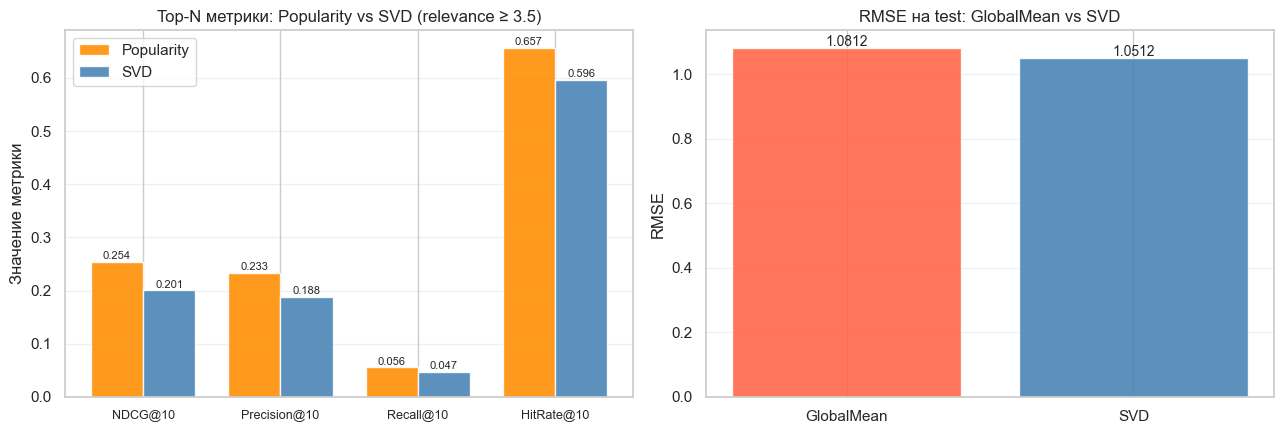

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

topn_metrics_names = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_topn        = ['Popularity', 'SVD (this notebook)']
x = np.arange(len(topn_metrics_names))
width = 0.38
colors = ['darkorange', 'steelblue']

for ax_idx, (model_name, color) in enumerate(zip(models_topn, colors)):
    row = comparison_df[comparison_df['Модель'] == model_name].iloc[0]
    vals = [float(row[m]) if row[m] is not None else 0.0
            for m in topn_metrics_names]
    bars = axes[0].bar(x + ax_idx * width, vals, width,
                       label=model_name.replace(' (this notebook)', ''),
                       color=color, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', fontsize=8)

axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(topn_metrics_names, fontsize=9)
axes[0].set_title(f'Top-N метрики: Popularity vs SVD (relevance ≥ {RELEVANCE_THRESHOLD})')
axes[0].set_ylabel('Значение метрики')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE comparison
rmse_models = ['GlobalMean', 'SVD']
rmse_vals = [gm_test['rmse'], svd_test_rating_metrics['rmse']]
bars = axes[1].bar(rmse_models, rmse_vals,
                   color=['tomato', 'steelblue'], alpha=0.88, edgecolor='white')
axes[1].set_title('RMSE на test: GlobalMean vs SVD')
axes[1].set_ylabel('RMSE')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'svd_vs_baseline.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Анализ ошибок

Где SVD ошибается сильнее всего?
Паттерны ошибок указывают на направление улучшений (контентные / гибридные модели).


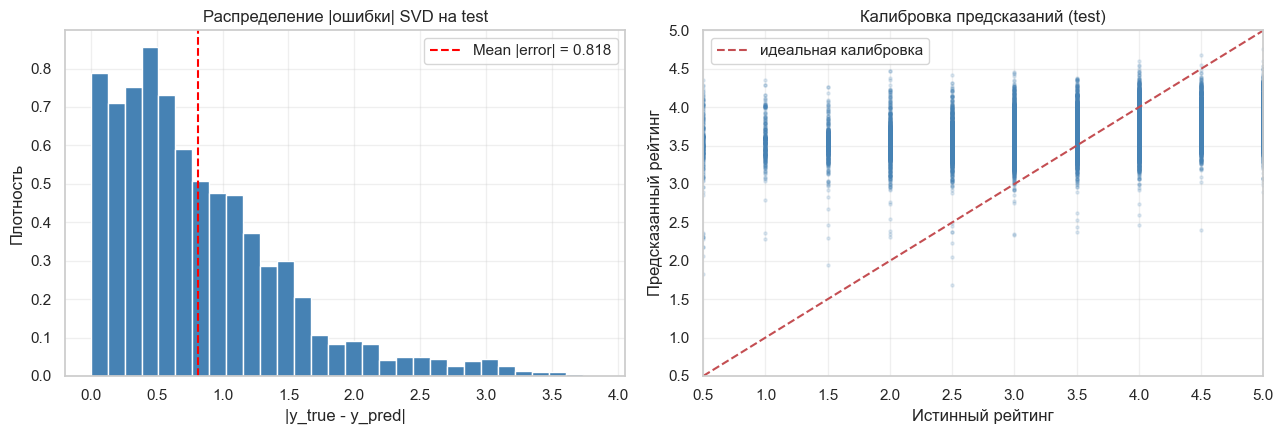

Диапазон предсказаний на test: [1.69, 4.75] (range = 3.06)
Std предсказаний: 0.270  (std истинных оценок: 1.071)
Чем ближе std предсказаний к std истинных, тем меньше «сжатие» к среднему.


In [17]:
# ── Распределение ошибок и калибровка ──────────────────────────────────
test_with_errors = test.copy()
test_with_errors['pred']  = test_preds
test_with_errors['error'] = np.abs(test['rating'].values - test_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Гистограмма ошибок
axes[0].hist(test_with_errors['error'], bins=30, color='steelblue',
             edgecolor='white', density=True)
axes[0].set_title('Распределение |ошибки| SVD на test')
axes[0].set_xlabel('|y_true - y_pred|')
axes[0].set_ylabel('Плотность')
axes[0].axvline(test_with_errors['error'].mean(), color='red', linestyle='--',
                label=f'Mean |error| = {test_with_errors["error"].mean():.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Калибровка: истинный vs предсказанный
axes[1].scatter(test_with_errors['rating'], test_with_errors['pred'],
                alpha=0.15, s=5, color='steelblue')
lims = [0.5, 5.0]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='идеальная калибровка')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Истинный рейтинг')
axes[1].set_ylabel('Предсказанный рейтинг')
axes[1].set_title('Калибровка предсказаний (test)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Диапазон предсказаний — ключевой признак отсутствия regression to mean ──
pred_range = test_preds.max() - test_preds.min()
pred_std   = test_preds.std()
print(f'Диапазон предсказаний на test: [{test_preds.min():.2f}, '
      f'{test_preds.max():.2f}] (range = {pred_range:.2f})')
print(f'Std предсказаний: {pred_std:.3f}  '
      f'(std истинных оценок: {test["rating"].std():.3f})')
print('Чем ближе std предсказаний к std истинных, тем меньше «сжатие» к среднему.')

In [18]:
# ── Топ-10 фильмов с наибольшей средней ошибкой ─────────────────────────
movie_error = (
    test_with_errors.groupby('movieId')['error']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
# Только фильмы с >= 3 оценками в test (иначе шум)
movie_error = movie_error[movie_error['n_test'] >= 3]
top_movie_errors = movie_error.nlargest(10, 'mean_error').merge(
    movies_enriched[['movieId', 'title']], on='movieId', how='left'
)
top_movie_errors['mean_error'] = top_movie_errors['mean_error'].round(3)
print('Топ-10 фильмов с наибольшей средней |ошибкой| (>= 3 оценки в test):')
display(top_movie_errors[['title', 'mean_error', 'n_test']])

Топ-10 фильмов с наибольшей средней |ошибкой| (>= 3 оценки в test):


,title,mean_error,n_test
0,Sense and Sensibility (1995),2.480,3
1,Catwoman (2004),2.238,3
2,Beethoven (1992),2.034,4
3,Grease 2 (1982),1.993,4
4,Big Momma's House (2000),1.950,3
5,Scary Movie 3 (2003),1.902,3
6,Ultraviolet (2006),1.874,4
7,Dungeons & Dragons (2000),1.817,3
8,Dr. Dolittle 2 (2001),1.773,3
9,Insurgent (2015),1.752,3


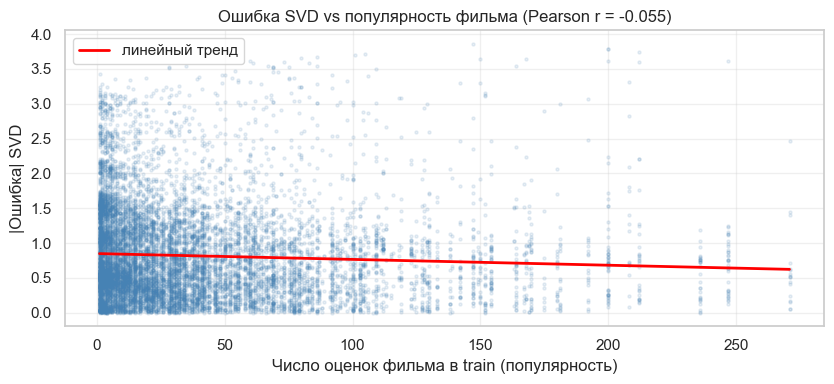

Pearson r (ошибка vs популярность): -0.0554
Отрицательная корреляция -> популярные фильмы предсказываются точнее (ожидаемо: больше данных -> лучше выученные факторы).


In [19]:
# ── Корреляция ошибки с популярностью фильма в train ───────────────────
movie_pop_train = train.groupby('movieId').size().reset_index(name='n_ratings_train')
error_vs_pop = test_with_errors.merge(movie_pop_train, on='movieId', how='left')

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.scatter(error_vs_pop['n_ratings_train'], error_vs_pop['error'],
           alpha=0.12, s=5, color='steelblue')

x_vals = error_vs_pop['n_ratings_train'].values
y_vals = error_vs_pop['error'].values
mask   = ~np.isnan(x_vals) & ~np.isnan(y_vals)

# Линейный тренд
coeffs = np.polyfit(x_vals[mask], y_vals[mask], 1)
x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
ax.plot(x_line, coeffs[1] + coeffs[0] * x_line,
        color='red', linewidth=2, label='линейный тренд')

corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Число оценок фильма в train (популярность)')
ax.set_ylabel('|Ошибка| SVD')
ax.set_title(f'Ошибка SVD vs популярность фильма (Pearson r = {corr:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pearson r (ошибка vs популярность): {corr:.4f}')
if corr < 0:
    print('Отрицательная корреляция -> популярные фильмы предсказываются точнее '
          '(ожидаемо: больше данных -> лучше выученные факторы).')
else:
    print('Положительная корреляция — нетипично, стоит проверить cold-start handling.')

## 9. Пример рекомендаций

Топ-N для нескольких реальных пользователей — проверка адекватности модели «на глаз».


In [20]:
sample_users = test_users[:3]
print(f'Пример рекомендаций SVD для {len(sample_users)} пользователей:\n')

title_lookup = movies_enriched.set_index('movieId')['title']

for u in sample_users:
    rec_ids = test_recs[u][:5]
    rec_titles = [title_lookup.get(mid, f'movie_{mid}') for mid in rec_ids]
    # Что человек оценил высоко в train+val (для контекста)
    seen_high = train_val[(train_val['userId'] == u) & (train_val['rating'] >= 4.5)]
    fav_ids = seen_high['movieId'].head(3).tolist()
    fav_titles = [title_lookup.get(mid, f'movie_{mid}') for mid in fav_ids]

    print(f'User {u}')
    print(f'  Любит:  {fav_titles}')
    print(f'  Топ-5:  {rec_titles}')
    print()

Пример рекомендаций SVD для 3 пользователей:

User 15
  Любит:  ['Lethal Weapon 2 (1989)', 'Gods Must Be Crazy, The (1980)', 'Frequency (2000)']
  Топ-5:  ['Shawshank Redemption, The (1994)', 'Godfather, The (1972)', "Schindler's List (1993)", 'Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)', 'Godfather: Part II, The (1974)']

User 18
  Любит:  ['Shawshank Redemption, The (1994)', 'Usual Suspects, The (1995)', 'Fight Club (1999)']
  Топ-5:  ['Princess Bride, The (1987)', 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)', 'Spirited Away (Sen to Chihiro no kamikakushi) (2001)', 'American Beauty (1999)', 'Casablanca (1942)']

User 21
  Любит:  ['Die Another Day (2002)', 'World Is Not Enough, The (1999)', 'Naked Gun 33 1/3: The Final Insult (1994)']
  Топ-5:  ['Shawshank Redemption, The (1994)', 'Casablanca (1942)', 'Princess Bride, The (1987)', "One Flew Over the Cuckoo's Nest (1975)", "Schindler's List (1993)"]



## 10. Сохранение артефактов


In [21]:
# Модель
joblib.dump(final_svd, MODELS_DIR / 'svd_model.pkl')
print(f"svd_model.pkl: {(MODELS_DIR / 'svd_model.pkl').stat().st_size / 1024:.1f} KB")

# Параметры
svd_params = {
    'random_state':                  SEED,
    'best_params':                   study.best_params,
    'optuna_n_trials':               N_TRIALS,
    'optuna_sampler':                'TPESampler',
    'optuna_direction':              'minimize',
    'optuna_target':                 f'-ndcg@{K_PRIMARY} on val',
    'relevance_threshold':           RELEVANCE_THRESHOLD,
    'final_train_strategy':          'train + val concatenated',
    'baseline_train_time_sec':       baseline_train_time,
    'optuna_search_time_sec':        optuna_time,
    'final_train_time_sec':          final_train_time,
    'inference_time_test_topn_sec':  inference_time,
}
with open(MODELS_DIR / 'svd_params.json', 'w', encoding='utf-8') as f:
    json.dump(svd_params, f, ensure_ascii=False, indent=2)

# Метрики
svd_metrics = {
    'baseline': {
        'val_rating': baseline_val_rating,
        'val_topn':   baseline_val_topn,
    },
    'final': {
        'val_best_ndcg10': float(best_ndcg10_val),
        'test_rating':     svd_test_rating_metrics,
        'test_topn':       svd_test_topn_metrics,
    },
    'popularity_recomputed_unified_threshold': pop_test_metrics_unified,
    'meta': {
        'k_values':              list(K_VALUES),
        'relevance_threshold':   RELEVANCE_THRESHOLD,
        'optuna_n_trials':       N_TRIALS,
        'optuna_target':         f'ndcg@{K_PRIMARY}',
    },
}
with open(MODELS_DIR / 'svd_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(svd_metrics, f, ensure_ascii=False, indent=2)

# История trials Optuna
trials_df = study.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'svd_optuna_trials.parquet', index=False)

print('Все артефакты сохранены.')
print(f'  Лучший NDCG@{K_PRIMARY} (val): {best_ndcg10_val:.4f}')
print(f'  RMSE (test):                  {svd_test_rating_metrics["rmse"]:.4f}')
print(f'  NDCG@10 (test):               {svd_test_topn_metrics["ndcg@10"]:.4f}')
print(f'  Precision@10 (test):          {svd_test_topn_metrics["precision@10"]:.4f}')
print(f'  Coverage@20 (test):           {svd_test_topn_metrics.get("coverage@20", 0):.4f}')

svd_model.pkl: 3763.2 KB
Все артефакты сохранены.
  Лучший NDCG@10 (val): 0.3013
  RMSE (test):                  1.0512
  NDCG@10 (test):               0.2005
  Precision@10 (test):          0.1879
  Coverage@20 (test):           0.0222


## 11. Итоги

| Что сделано | Результат |
|-------------|-----------|
| SVD обучена через `surprise`, Optuna 30 trials по NDCG@10 | best NDCG@10 val = 0.3013 |
| Оценка по rating (RMSE/MAE) и ranking (NDCG, P, R, HR, Coverage) | NDCG@10 test = 0.2005 |
| Честное сравнение с Popularity под единым порогом 3.5 | SVD уступает Popularity по NDCG@10 |

> **Главный урок:** оптимизация по RMSE рассыпает top-N ранжирование из-за regression to the mean.
> Если цель — top-N, Optuna должна оптимизировать ranking-метрику.
